In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold



from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

### EDA 

In [3]:
df = pd.read_csv("UAReviews.csv")

df.head()

,id,rating,content,source,final_emotion,final_category,length,split
0,622,1.0,Жахливе місце. Жахлива черга. Ніхто нічого під...,original,Anger,Complaint / Dissatisfaction,61,train
1,15442,1.0,"Жахливе відношення до людей,які записані на о...",original,Anger,Complaint / Dissatisfaction,174,train
2,3201,3.0,"Як були черги величезні та багатогодинні, так ...",original,Anger,Complaint / Dissatisfaction,238,train
3,13484,NaN,Сьогодні відвідала ЦНАП(була екскурсія від іні...,original,Happiness,Gratitude / Positive Feedback,241,train
4,6777,1.0,Пиляток на всьому. Ряд об'єктів почали і не до...,original,Anger,Complaint / Dissatisfaction,53,train


In [4]:
df.shape

(11580, 8)

In [5]:
df.columns.tolist()

['id',
 'rating',
 'content',
 'source',
 'final_emotion',
 'final_category',
 'length',
 'split']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11580 entries, 0 to 11579
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              11580 non-null  int64  
 1   rating          10252 non-null  float64
 2   content         11580 non-null  object 
 3   source          11580 non-null  object 
 4   final_emotion   11580 non-null  object 
 5   final_category  11580 non-null  object 
 6   length          11580 non-null  int64  
 7   split           11580 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 723.9+ KB


In [7]:
missing = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

display(missing_table)

,missing_count,missing_percent
content,0,0.00
final_category,0,0.00
final_emotion,0,0.00
id,0,0.00
length,0,0.00
rating,1328,11.47
source,0,0.00
split,0,0.00


In [8]:
print("Кількість повністю дубльованих рядків:", df.duplicated().sum())

if "content" in df.columns:
    print("Кількість дублікатів у текстах:", df["content"].duplicated().sum())

Кількість повністю дубльованих рядків: 0
Кількість дублікатів у текстах: 15


final_category
Gratitude / Positive Feedback    7440
Complaint / Dissatisfaction      2730
Question / Request for Help       615
Neutral Comment                   418
Suggestion / Idea                 377
Name: count, dtype: int64

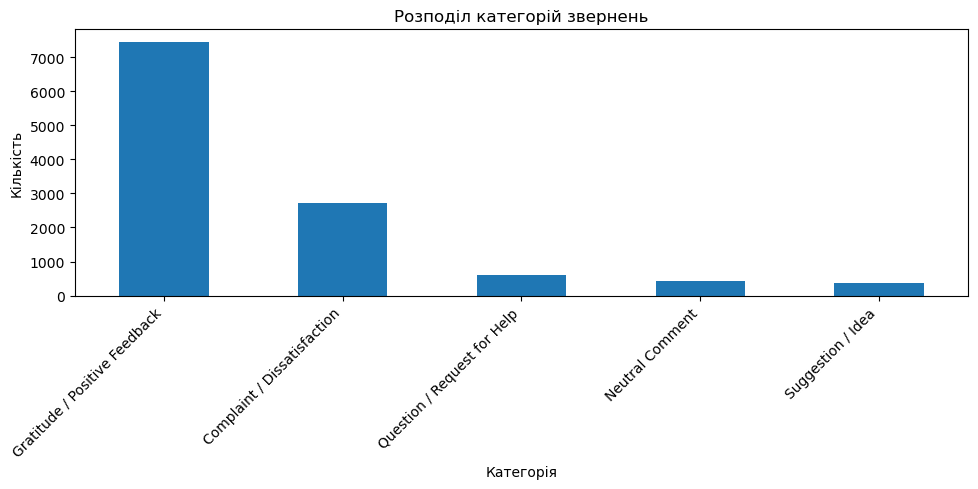

In [9]:
category_counts = df["final_category"].value_counts()

display(category_counts)

plt.figure(figsize=(10, 5))
category_counts.plot(kind="bar")
plt.title("Розподіл категорій звернень")
plt.xlabel("Категорія")
plt.ylabel("Кількість")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

final_emotion
Happiness    7557
Anger        2264
Neutral      1117
Sadness       424
Disgust       106
Surprise       57
Fear           55
Name: count, dtype: int64

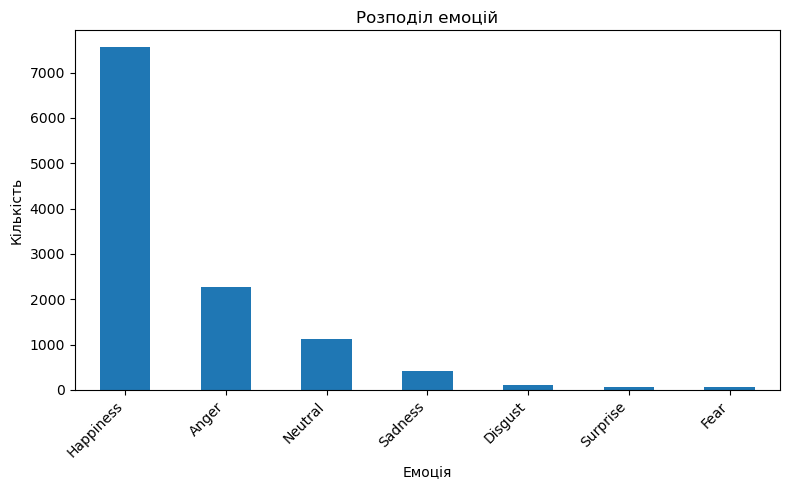

In [10]:
emotion_counts = df["final_emotion"].value_counts()

display(emotion_counts)

plt.figure(figsize=(8, 5))
emotion_counts.plot(kind="bar")
plt.title("Розподіл емоцій")
plt.xlabel("Емоція")
plt.ylabel("Кількість")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

split
train        8106
test         1737
challenge    1737
Name: count, dtype: int64

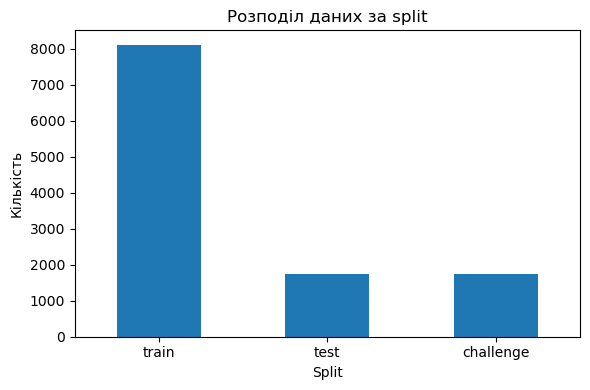

In [11]:
split_counts = df["split"].value_counts()

display(split_counts)

plt.figure(figsize=(6, 4))
split_counts.plot(kind="bar")
plt.title("Розподіл даних за split")
plt.xlabel("Split")
plt.ylabel("Кількість")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

rating
1.0    1833
2.0     245
3.0     252
4.0     539
5.0    7383
NaN    1328
Name: count, dtype: int64

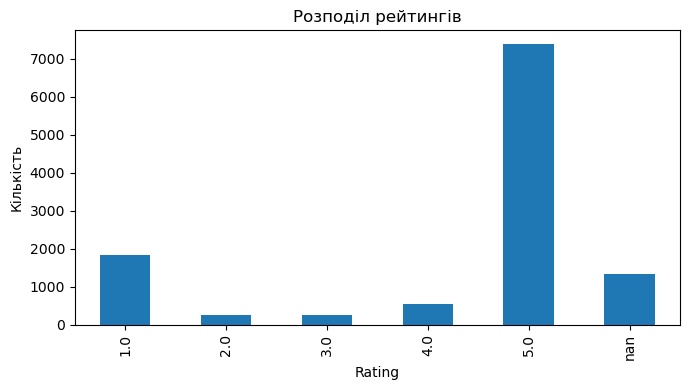

In [12]:
rating_counts = df["rating"].value_counts(dropna=False).sort_index()

display(rating_counts)

plt.figure(figsize=(7, 4))
rating_counts.plot(kind="bar")
plt.title("Розподіл рейтингів")
plt.xlabel("Rating")
plt.ylabel("Кількість")
plt.tight_layout()
plt.show()

,text_length,word_count
count,11580.000000,11580.000000
mean,147.724352,21.364421
std,83.172210,12.749089
min,51.000000,1.000000
25%,82.000000,11.000000
50%,129.000000,18.000000
75%,211.000000,30.000000
max,1691.000000,283.000000


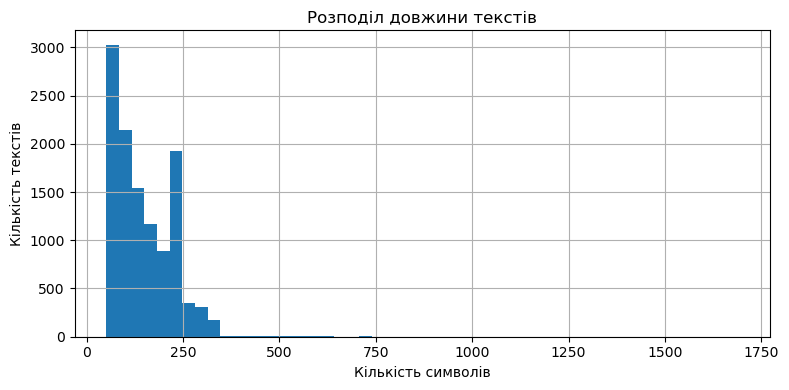

In [13]:
df["text_length"] = df["content"].astype(str).str.len()
df["word_count"] = df["content"].astype(str).str.split().str.len()

display(df[["text_length", "word_count"]].describe())

plt.figure(figsize=(8, 4))
df["text_length"].hist(bins=50)
plt.title("Розподіл довжини текстів")
plt.xlabel("Кількість символів")
plt.ylabel("Кількість текстів")
plt.tight_layout()
plt.show()

,text_length,word_count
final_category,,
Complaint / Dissatisfaction,162.03,24.79
Gratitude / Positive Feedback,141.80,19.92
Neutral Comment,138.00,19.69
Question / Request for Help,152.21,22.92
Suggestion / Idea,164.58,24.35


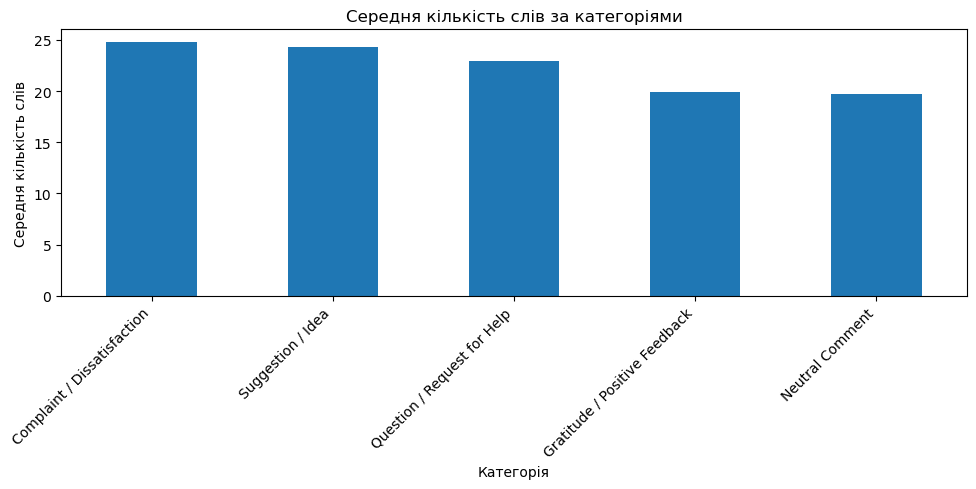

In [25]:
length_by_category = df.groupby("final_category")[["text_length", "word_count"]].mean().round(2)

display(length_by_category)

plt.figure(figsize=(10, 5))
length_by_category["word_count"].sort_values(ascending=False).plot(kind="bar")
plt.title("Середня кількість слів за категоріями")
plt.xlabel("Категорія")
plt.ylabel("Середня кількість слів")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [14]:
for category in df["final_category"].unique():
    print("=" * 80)
    print("Категорія:", category)
    display(df[df["final_category"] == category][["content", "final_emotion", "rating"]].head(3))

Категорія: Complaint / Dissatisfaction


,content,final_emotion,rating
0,Жахливе місце. Жахлива черга. Ніхто нічого під...,Anger,1.0
1,"Жахливе відношення до людей,які записані на о...",Anger,1.0
2,"Як були черги величезні та багатогодинні, так ...",Anger,3.0


Категорія: Gratitude / Positive Feedback


,content,final_emotion,rating
3,Сьогодні відвідала ЦНАП(була екскурсія від іні...,Happiness,NaN
6,Напередодні зареєструвалась в онлайн черзі. Ме...,Happiness,5.0
8,"Півгодини перечитував і ""лайкав коментарі"")). ...",Happiness,5.0


Категорія: Question / Request for Help


,content,final_emotion,rating
5,"Вступив на ІСТ цього року, тепер молюся, щоб п...",Happiness,2.0
7,"а по факту ми і дальше просимо боєприпаси,ппо,...",Sadness,NaN
39,Цифрова держава Повідомлення 123 від 18.04.202...,Neutral,NaN


Категорія: Neutral Comment


,content,final_emotion,rating
41,Старий університет поки що вчить. Наразі налаш...,Neutral,5.0
48,Шевченківський суд втратив свою першість з поя...,Neutral,5.0
88,Сьогодні відкриття військової кафедри. Ще один...,Happiness,NaN


Категорія: Suggestion / Idea


,content,final_emotion,rating
89,"Мені здається, що наша кузня супер-кадрів в IT...",Neutral,3.0
95,Дуже красивий ансамбль будівель. При відвідува...,Happiness,5.0
123,Радимо звернутись щодо цього питання на пошту ...,Neutral,NaN


,word,count
0,все,2116
1,дякую,1608
2,швидко,1065
3,рекомендую,1045
4,місце,688
5,всі,667
6,можна,652
7,питання,640
8,якщо,627
9,була,626


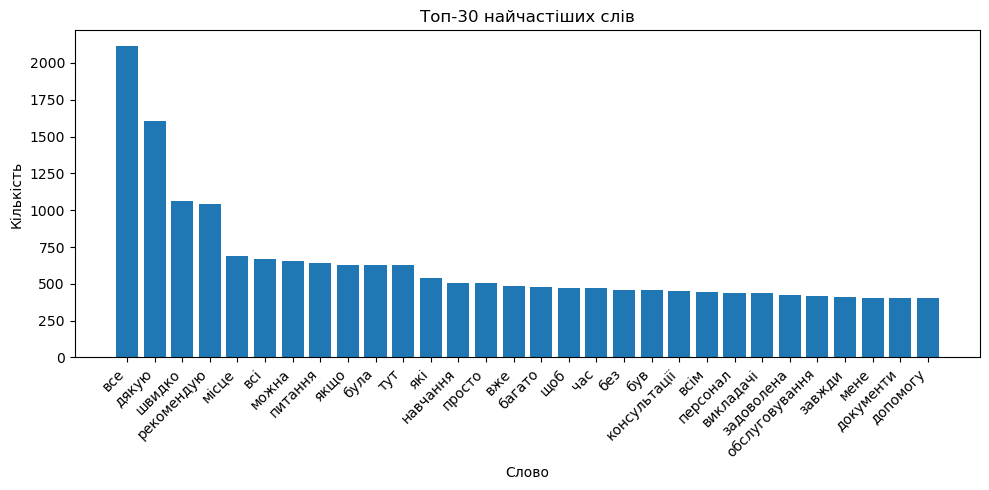

In [15]:
stopwords = {
    "і", "в", "у", "на", "не", "що", "з", "до", "та", "я", "це", "є",
    "за", "по", "як", "але", "для", "то", "мені", "ми", "ви", "а",
    "про", "так", "від", "було", "дуже", "ще", "чи"
}

texts = " ".join(df["content"].astype(str).str.lower())

words = re.findall(r"[а-яіїєґa-z]+", texts)
words = [word for word in words if word not in stopwords and len(word) > 2]

word_freq = Counter(words).most_common(30)

word_freq_df = pd.DataFrame(word_freq, columns=["word", "count"])
display(word_freq_df)

plt.figure(figsize=(10, 5))
plt.bar(word_freq_df["word"], word_freq_df["count"])
plt.title("Топ-30 найчастіших слів")
plt.xlabel("Слово")
plt.ylabel("Кількість")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [26]:
print("Короткий підсумок:")
print(f"Кількість рядків: {df.shape[0]}")
print(f"Кількість колонок: {df.shape[1]}")
print(f"Кількість категорій: {df['final_category'].nunique()}")
print(f"Кількість емоцій: {df['final_emotion'].nunique()}")
print(f"Пропущені значення у rating: {df['rating'].isna().sum()}")
print(f"Середня довжина тексту в словах: {df['word_count'].mean():.2f}")
print(f"Медіанна довжина тексту в словах: {df['word_count'].median():.2f}")

Короткий підсумок:
Кількість рядків: 11580
Кількість колонок: 11
Кількість категорій: 5
Кількість емоцій: 7
Пропущені значення у rating: 1328
Середня довжина тексту в словах: 21.36
Медіанна довжина тексту в словах: 18.00


### Препроцесинг

In [27]:
def clean_text(text):
    text = str(text).lower()
    
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    
    text = re.sub(r"@\w+", " ", text)
    
    text = re.sub(r"\d+", " ", text)
    
    text = re.sub(r"[^а-яіїєґa-z\s]", " ", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [28]:
df["clean_content"] = df["content"].apply(clean_text)

df[["content", "clean_content"]].head()

,content,clean_content
0,Жахливе місце. Жахлива черга. Ніхто нічого під...,жахливе місце жахлива черга ніхто нічого підка...
1,"Жахливе відношення до людей,які записані на о...",жахливе відношення до людей які записані на од...
2,"Як були черги величезні та багатогодинні, так ...",як були черги величезні та багатогодинні так і...
3,Сьогодні відвідала ЦНАП(була екскурсія від іні...,сьогодні відвідала цнап була екскурсія від іні...
4,Пиляток на всьому. Ряд об'єктів почали і не до...,пиляток на всьому ряд об єктів почали і не дор...


In [29]:
for i in range(5):
    print("Оригінал:")
    print(df.loc[i, "content"])
    print("\nПісля очистки:")
    print(df.loc[i, "clean_content"])
    print("-" * 80)

Оригінал:
Жахливе місце. Жахлива черга. Ніхто нічого підказати не може.

Після очистки:
жахливе місце жахлива черга ніхто нічого підказати не може
--------------------------------------------------------------------------------
Оригінал:
Жахливе відношення до людей,які  записані на один час, а чекають набагато довше.Не рекомендую,через те що люди розплановують собі день,а чекати під дверима потрібно довго!!!!

Після очистки:
жахливе відношення до людей які записані на один час а чекають набагато довше не рекомендую через те що люди розплановують собі день а чекати під дверима потрібно довго
--------------------------------------------------------------------------------
Оригінал:
Як були черги величезні та багатогодинні, так і залишилися. Ганьба. Електронна хвалена черга приймає запис із мого питання 20 жовтня на 7 листопада найближча дата. У результаті просто пекло!  я 242 у черзі, людей у черзі з мого ж питання…

Після очистки:
як були черги величезні та багатогодинні так і залишилис

In [30]:
X = df["clean_content"]
y = df["final_category"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
tfidf_check = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf_check = tfidf_check.fit_transform(X_train)

print("Кількість TF-IDF фіч без max_features:", X_train_tfidf_check.shape[1])

Кількість TF-IDF фіч без max_features: 26850


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

max_features_list = [5000, 10000, 15000, 20000, 25000, None]

results_features = []

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for max_features in max_features_list:
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            max_features=max_features,
            sublinear_tf=True
        )),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="saga",
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )
    
    results_features.append({
        "max_features": max_features,
        "mean_f1_macro": scores.mean(),
        "std_f1_macro": scores.std()
    })

features_results_df = pd.DataFrame(results_features)
features_results_df = features_results_df.sort_values(by="mean_f1_macro", ascending=False)

display(features_results_df)

,max_features,mean_f1_macro,std_f1_macro
4,25000.0,0.564066,0.041905
5,NaN,0.564066,0.041905
1,10000.0,0.537517,0.064256
0,5000.0,0.476662,0.118567
3,20000.0,0.468971,0.145329
2,15000.0,0.406326,0.174942


: 

: 

: 

: 

: 

: 

In [33]:
plot_df = features_results_df.copy()

plot_df["max_features_label"] = plot_df["max_features"].apply(
    lambda x: "None" if pd.isna(x) else str(int(x))
)

order = ["5000", "10000", "15000", "20000", "25000", "None"]

plot_df["max_features_label"] = pd.Categorical(
    plot_df["max_features_label"],
    categories=order,
    ordered=True
)

plot_df = plot_df.sort_values("max_features_label")

plt.figure(figsize=(9, 5))
plt.plot(
    plot_df["max_features_label"],
    plot_df["mean_f1_macro"],
    marker="o"
)

plt.title("Підбір кількості TF-IDF ознак")
plt.xlabel("max_features")
plt.ylabel("Mean macro F1-score")
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'features_results_df' is not defined

In [34]:
best_max_features = 25000

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=best_max_features,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


print("Train TF-IDF:", X_train_tfidf.shape)
print("Test TF-IDF:", X_test_tfidf.shape)


Train TF-IDF: (9264, 25000)
Test TF-IDF: (2316, 25000)


### Логістична регресія

In [35]:
logreg_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

logreg_model.fit(X_train_tfidf, y_train)

logreg_pred = logreg_model.predict(X_test_tfidf)

print(classification_report(y_test, logreg_pred, zero_division=0))

                               precision    recall  f1-score   support

  Complaint / Dissatisfaction       0.76      0.83      0.79       546
Gratitude / Positive Feedback       0.94      0.87      0.90      1488
              Neutral Comment       0.31      0.46      0.38        84
  Question / Request for Help       0.78      0.83      0.81       123
            Suggestion / Idea       0.33      0.41      0.37        75

                     accuracy                           0.83      2316
                    macro avg       0.63      0.68      0.65      2316
                 weighted avg       0.85      0.83      0.84      2316



<Figure size 900x700 with 0 Axes>

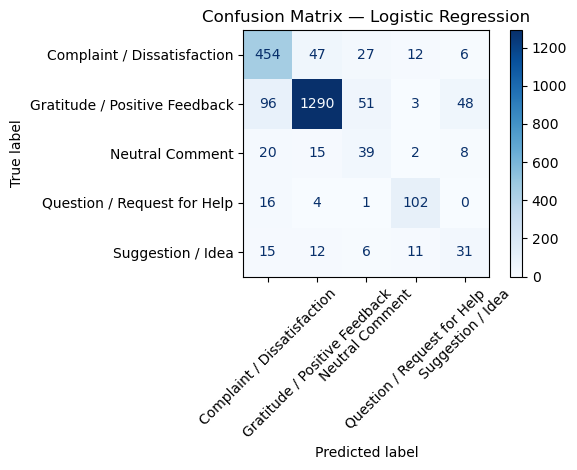

In [36]:
labels = sorted(y_test.unique())

cm = confusion_matrix(
    y_test,
    logreg_pred,
    labels=labels
)

plt.figure(figsize=(9, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
     cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

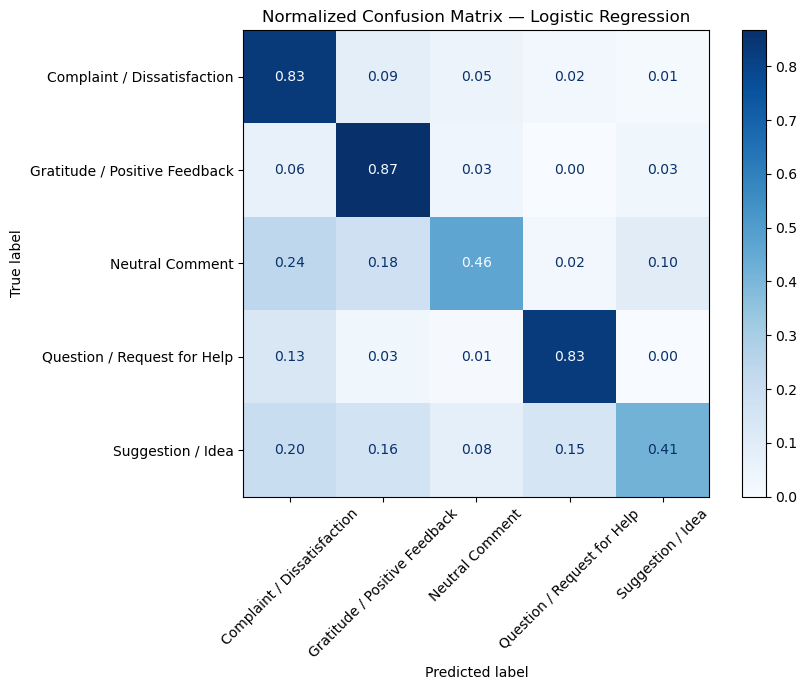

In [37]:
cm_norm = confusion_matrix(
    y_test,
    logreg_pred,
    labels=labels,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

### Логістична регресія з тюнингом гіперпараметрів

In [38]:
logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        max_features=25000,
        sublinear_tf=True
    )),
    ("model", LogisticRegression(
        solver="liblinear",
        max_iter=1000,
        random_state=42
    ))
])

In [39]:
param_grid = {
    "model__C": [0.1, 0.3, 1, 3, 10],
    "model__penalty": ["l1", "l2"],
    "model__class_weight": [None, "balanced"]
}

In [40]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search_logreg = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search_logreg.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_df=0.95,
                                                        max_features=25000,
                                                        min_df=2,
                                                        ngram_range=(1, 2),
                                                        sublinear_tf=True)),
                                       ('model',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42,
                                                           solver='liblinear'))]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 0.3, 1, 3, 10],
                         'model__class_weight': [None, 'balanced'],
                         'model__penalty': ['l1', 'l2']},
             return_train_score=True, scoring='f1_macro', verbose=1)

In [ ]:
print("Найкращі параметри:")
print(grid_search_logreg.best_params_)

print("\nНайкращий CV macro F1:")
print(grid_search_logreg.best_score_)

Найкращі параметри:
{'model__C': 10, 'model__class_weight': 'balanced', 'model__penalty': 'l2'}

Найкращий CV macro F1:
0.6548364028662725


: 

: 

: 

: 

: 

: 

In [41]:
best_logreg_model = grid_search_logreg.best_estimator_

tuned_logreg_pred = best_logreg_model.predict(X_test)

print("Tuned Logistic Regression")
print(classification_report(y_test, tuned_logreg_pred, zero_division=0))

Tuned Logistic Regression
                               precision    recall  f1-score   support

  Complaint / Dissatisfaction       0.80      0.84      0.82       546
Gratitude / Positive Feedback       0.92      0.94      0.93      1488
              Neutral Comment       0.49      0.30      0.37        84
  Question / Request for Help       0.81      0.80      0.80       123
            Suggestion / Idea       0.46      0.31      0.37        75

                     accuracy                           0.87      2316
                    macro avg       0.70      0.64      0.66      2316
                 weighted avg       0.86      0.87      0.86      2316



In [42]:
tuned_logreg_metrics = {
    "model": "Tuned Logistic Regression",
    "accuracy": accuracy_score(y_test, tuned_logreg_pred),
    "precision_macro": precision_score(y_test, tuned_logreg_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, tuned_logreg_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, tuned_logreg_pred, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_test, tuned_logreg_pred, average="weighted", zero_division=0)
}

display(pd.DataFrame([tuned_logreg_metrics]))

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Tuned Logistic Regression,0.865717,0.695911,0.636743,0.6584,0.859376


In [43]:
baseline_logreg_metrics = {
    "model": "Baseline Logistic Regression",
    "accuracy": accuracy_score(y_test, logreg_pred),
    "precision_macro": precision_score(y_test, logreg_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, logreg_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, logreg_pred, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_test, logreg_pred, average="weighted", zero_division=0)
}

comparison_logreg = pd.DataFrame([
    baseline_logreg_metrics,
    tuned_logreg_metrics
])

display(comparison_logreg)

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Baseline Logistic Regression,0.827288,0.626171,0.681065,0.649073,0.835401
1,Tuned Logistic Regression,0.865717,0.695911,0.636743,0.658400,0.859376


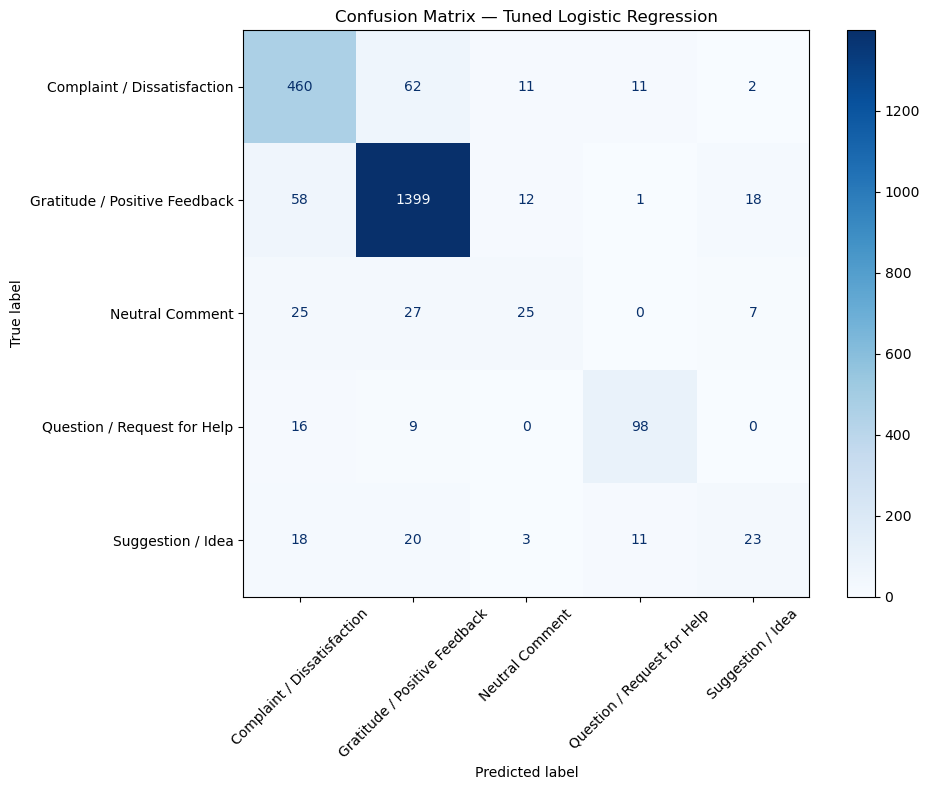

In [44]:
labels = sorted(y_test.unique())

cm_tuned = confusion_matrix(
    y_test,
    tuned_logreg_pred,
    labels=labels
)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix — Tuned Logistic Regression")
plt.tight_layout()
plt.show()

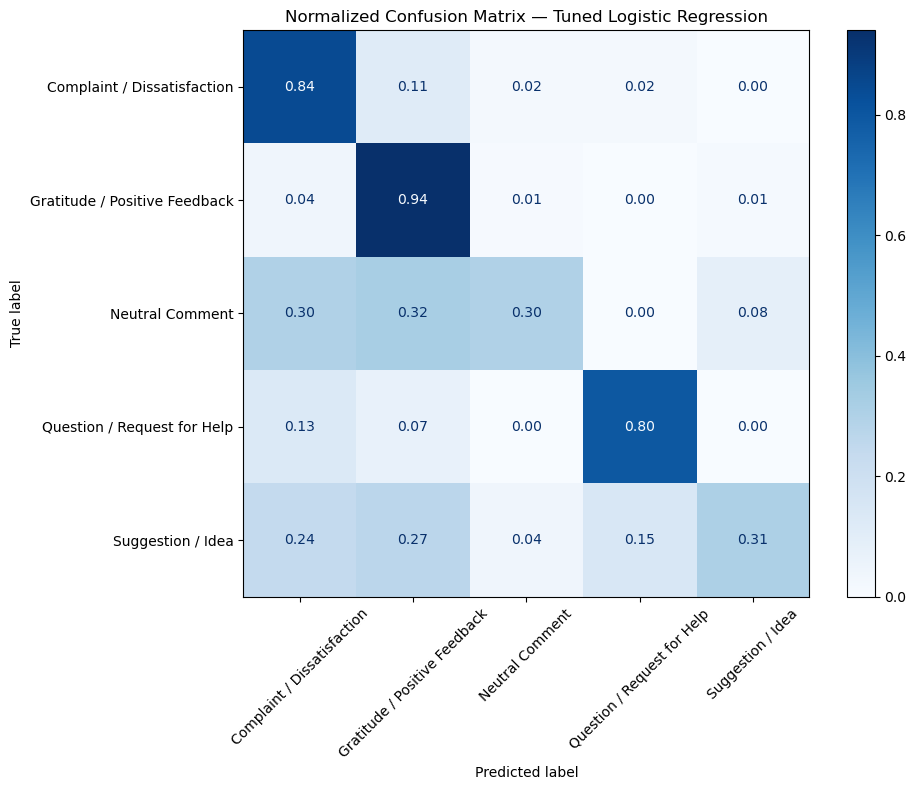

In [45]:
cm_tuned_norm = confusion_matrix(
    y_test,
    tuned_logreg_pred,
    labels=labels,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned_norm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix — Tuned Logistic Regression")
plt.tight_layout()
plt.show()

### Naive Bayes

In [46]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes — Baseline")
print(classification_report(y_test, nb_pred, zero_division=0))

Naive Bayes — Baseline
                               precision    recall  f1-score   support

  Complaint / Dissatisfaction       0.84      0.65      0.73       546
Gratitude / Positive Feedback       0.80      0.99      0.88      1488
              Neutral Comment       0.00      0.00      0.00        84
  Question / Request for Help       1.00      0.37      0.54       123
            Suggestion / Idea       0.00      0.00      0.00        75

                     accuracy                           0.81      2316
                    macro avg       0.53      0.40      0.43      2316
                 weighted avg       0.76      0.81      0.77      2316



In [47]:
nb_metrics = {
    "model": "Naive Bayes",
    "accuracy": accuracy_score(y_test, nb_pred),
    "precision_macro": precision_score(y_test, nb_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, nb_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, nb_pred, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_test, nb_pred, average="weighted", zero_division=0)
}

display(pd.DataFrame([nb_metrics]))

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Naive Bayes,0.809154,0.527684,0.401326,0.430523,0.768959


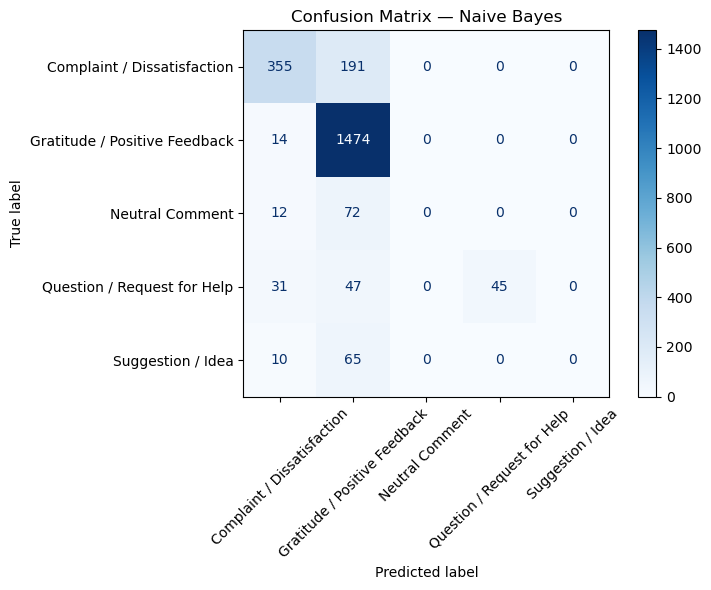

In [48]:
labels = sorted(y_test.unique())

cm_nb = confusion_matrix(
    y_test,
    nb_pred,
    labels=labels
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix — Naive Bayes")
plt.tight_layout()
plt.show()

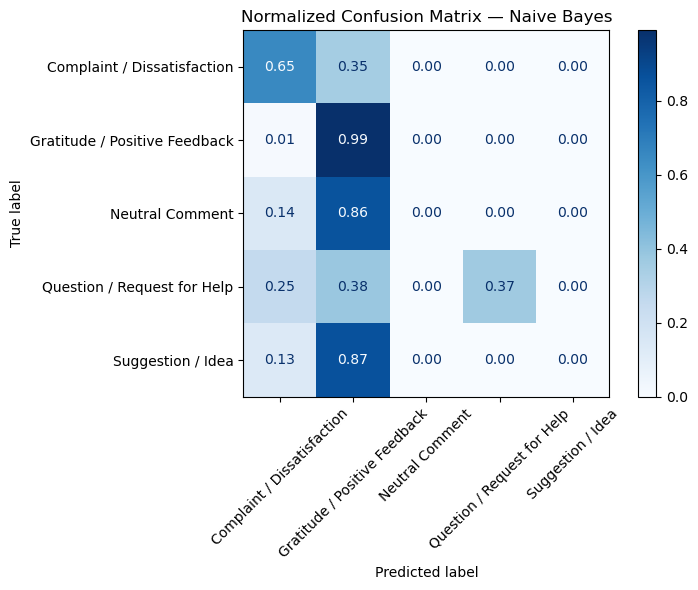

In [49]:
cm_nb_norm = confusion_matrix(
    y_test,
    nb_pred,
    labels=labels,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb_norm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix — Naive Bayes")
plt.tight_layout()
plt.show()

In [50]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        max_features=25000,
        sublinear_tf=True
    )),
    ("model", MultinomialNB())
])

param_grid_nb = {
    "model__alpha": [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search_nb = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=param_grid_nb,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search_nb.fit(X_train, y_train)

Fitting 5 folds for each of 7 candidates, totalling 35 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_df=0.95,
                                                        max_features=25000,
                                                        min_df=2,
                                                        ngram_range=(1, 2),
                                                        sublinear_tf=True)),
                                       ('model', MultinomialNB())]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0]},
             return_train_score=True, scoring='f1_macro', verbose=1)

In [51]:
print("Найкращі параметри Naive Bayes:")
print(grid_search_nb.best_params_)

print("\nНайкращий CV macro F1:")
print(grid_search_nb.best_score_)

Найкращі параметри Naive Bayes:
{'model__alpha': 0.01}

Найкращий CV macro F1:
0.6286879104497374


In [52]:
nb_grid_results = pd.DataFrame(grid_search_nb.cv_results_)

nb_results_table = nb_grid_results[[
    "param_model__alpha",
    "mean_test_score",
    "std_test_score",
    "mean_train_score"
]].sort_values(by="mean_test_score", ascending=False)

display(nb_results_table)

,param_model__alpha,mean_test_score,std_test_score,mean_train_score
0,0.01,0.628688,0.016373,0.970575
1,0.05,0.620444,0.016080,0.961203
2,0.10,0.597035,0.018353,0.928268
3,0.30,0.502292,0.016311,0.714484
4,0.50,0.442960,0.003970,0.579287
5,1.00,0.380218,0.004132,0.453703
6,2.00,0.297514,0.008925,0.352874


In [53]:
best_nb_model = grid_search_nb.best_estimator_

tuned_nb_pred = best_nb_model.predict(X_test)

print("Tuned Naive Bayes")
print(classification_report(y_test, tuned_nb_pred, zero_division=0))

Tuned Naive Bayes
                               precision    recall  f1-score   support

  Complaint / Dissatisfaction       0.78      0.83      0.80       546
Gratitude / Positive Feedback       0.90      0.93      0.92      1488
              Neutral Comment       0.55      0.25      0.34        84
  Question / Request for Help       0.91      0.77      0.84       123
            Suggestion / Idea       0.36      0.25      0.30        75

                     accuracy                           0.85      2316
                    macro avg       0.70      0.61      0.64      2316
                 weighted avg       0.84      0.85      0.85      2316



In [54]:
tuned_nb_metrics = {
    "model": "Tuned Naive Bayes",
    "accuracy": accuracy_score(y_test, tuned_nb_pred),
    "precision_macro": precision_score(y_test, tuned_nb_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, tuned_nb_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, tuned_nb_pred, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_test, tuned_nb_pred, average="weighted", zero_division=0)
}

display(pd.DataFrame([tuned_nb_metrics]))

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Tuned Naive Bayes,0.853195,0.700988,0.607168,0.639482,0.845049


In [55]:
comparison_nb = pd.DataFrame([
    nb_metrics,
    tuned_nb_metrics
])

display(comparison_nb)

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Naive Bayes,0.809154,0.527684,0.401326,0.430523,0.768959
1,Tuned Naive Bayes,0.853195,0.700988,0.607168,0.639482,0.845049


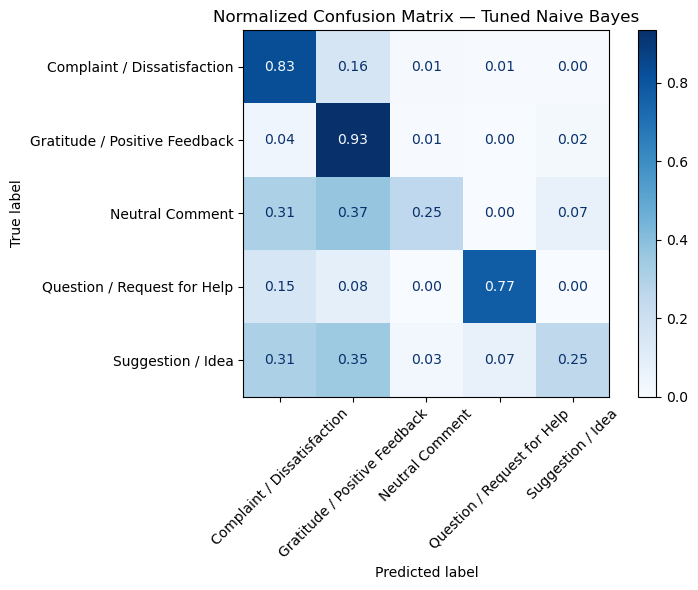

In [56]:
cm_tuned_nb_norm = confusion_matrix(
    y_test,
    tuned_nb_pred,
    labels=labels,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned_nb_norm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix — Tuned Naive Bayes")
plt.tight_layout()
plt.show()


### LinearSVC

In [57]:
svc_model = LinearSVC(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

svc_model.fit(X_train_tfidf, y_train)

svc_pred = svc_model.predict(X_test_tfidf)

print("LinearSVC — Baseline")
print(classification_report(y_test, svc_pred, zero_division=0))

LinearSVC — Baseline
                               precision    recall  f1-score   support

  Complaint / Dissatisfaction       0.79      0.84      0.81       546
Gratitude / Positive Feedback       0.93      0.94      0.93      1488
              Neutral Comment       0.48      0.32      0.39        84
  Question / Request for Help       0.79      0.80      0.80       123
            Suggestion / Idea       0.44      0.32      0.37        75

                     accuracy                           0.86      2316
                    macro avg       0.69      0.64      0.66      2316
                 weighted avg       0.86      0.86      0.86      2316



In [58]:
svc_metrics = {
    "model": "LinearSVC",
    "accuracy": accuracy_score(y_test, svc_pred),
    "precision_macro": precision_score(y_test, svc_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, svc_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, svc_pred, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_test, svc_pred, average="weighted", zero_division=0)
}

display(pd.DataFrame([svc_metrics]))

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,LinearSVC,0.863558,0.687452,0.64366,0.66019,0.85852


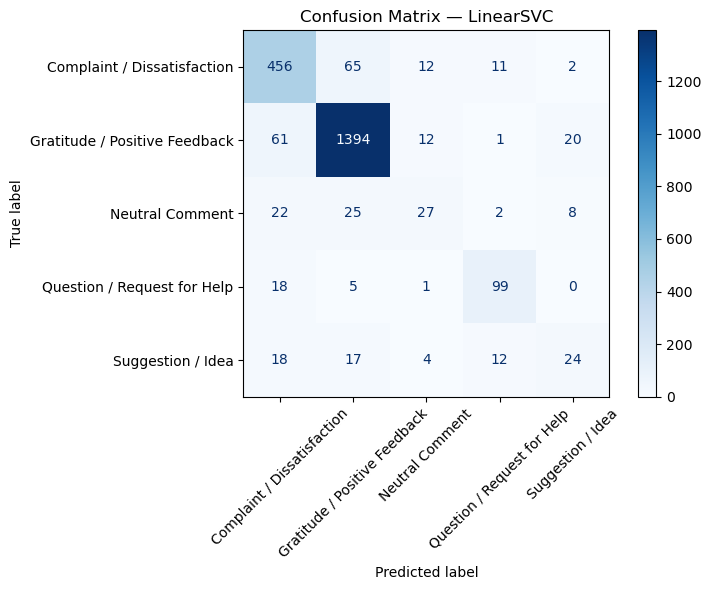

In [59]:
labels = sorted(y_test.unique())

cm_svc = confusion_matrix(
    y_test,
    svc_pred,
    labels=labels
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svc,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix — LinearSVC")
plt.tight_layout()
plt.show()

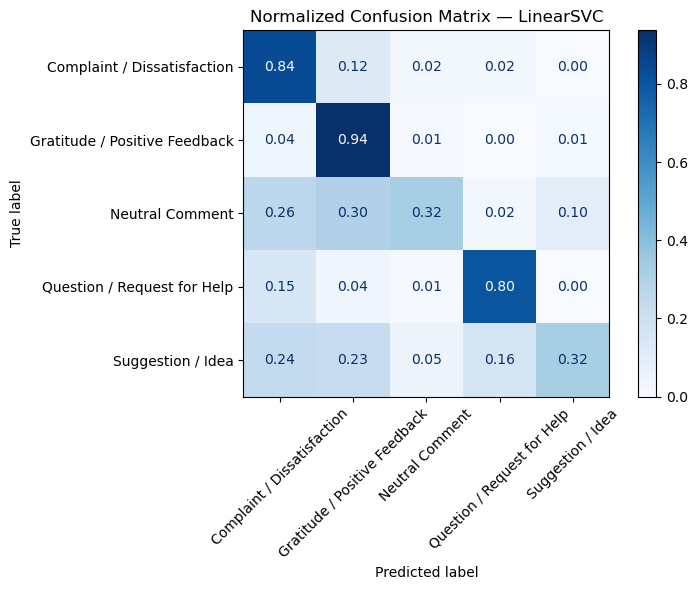

In [60]:
cm_svc_norm = confusion_matrix(
    y_test,
    svc_pred,
    labels=labels,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svc_norm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix — LinearSVC")
plt.tight_layout()
plt.show()

### tuning LinearSVC

In [61]:
svc_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        max_features=25000,
        sublinear_tf=True
    )),
    ("model", LinearSVC(
        max_iter=5000,
        random_state=42
    ))
])

param_grid_svc = {
    "model__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
    "model__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search_svc = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=param_grid_svc,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search_svc.fit(X_train, y_train)

Fitting 5 folds for each of 14 candidates, totalling 70 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_df=0.95,
                                                        max_features=25000,
                                                        min_df=2,
                                                        ngram_range=(1, 2),
                                                        sublinear_tf=True)),
                                       ('model',
                                        LinearSVC(max_iter=5000,
                                                  random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
                         'model__class_weight': [None, 'balanced']},
             return_train_score=True, scoring='f1_macro', verbose=1)

In [62]:
print("Найкращі параметри LinearSVC:")
print(grid_search_svc.best_params_)

print("\nНайкращий CV macro F1:")
print(grid_search_svc.best_score_)

Найкращі параметри LinearSVC:
{'model__C': 0.3, 'model__class_weight': 'balanced'}

Найкращий CV macro F1:
0.6627787677433241


In [63]:
svc_grid_results = pd.DataFrame(grid_search_svc.cv_results_)

svc_results_table = svc_grid_results[[
    "param_model__C",
    "param_model__class_weight",
    "mean_test_score",
    "std_test_score",
    "mean_train_score"
]].sort_values(by="mean_test_score", ascending=False)

display(svc_results_table)

,param_model__C,param_model__class_weight,mean_test_score,std_test_score,mean_train_score
7,0.30,balanced,0.662779,0.012819,0.979918
9,1.00,balanced,0.658580,0.018250,0.996373
5,0.10,balanced,0.654424,0.007908,0.941346
11,3.00,balanced,0.652235,0.009416,0.997541
13,10.00,balanced,0.651862,0.006952,0.998905
12,10.00,None,0.638843,0.017187,0.997972
10,3.00,None,0.636810,0.016349,0.997971
3,0.03,balanced,0.623407,0.007461,0.864288
8,1.00,None,0.621113,0.014461,0.996181
6,0.30,None,0.586090,0.016000,0.913750


In [64]:
best_svc_model = grid_search_svc.best_estimator_

tuned_svc_pred = best_svc_model.predict(X_test)

print("Tuned LinearSVC")
print(classification_report(y_test, tuned_svc_pred, zero_division=0))

Tuned LinearSVC
                               precision    recall  f1-score   support

  Complaint / Dissatisfaction       0.79      0.84      0.81       546
Gratitude / Positive Feedback       0.93      0.92      0.93      1488
              Neutral Comment       0.43      0.35      0.38        84
  Question / Request for Help       0.80      0.82      0.81       123
            Suggestion / Idea       0.41      0.35      0.37        75

                     accuracy                           0.86      2316
                    macro avg       0.67      0.66      0.66      2316
                 weighted avg       0.85      0.86      0.86      2316



In [65]:
tuned_svc_metrics = {
    "model": "Tuned LinearSVC",
    "accuracy": accuracy_score(y_test, tuned_svc_pred),
    "precision_macro": precision_score(y_test, tuned_svc_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, tuned_svc_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, tuned_svc_pred, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_test, tuned_svc_pred, average="weighted", zero_division=0)
}

display(pd.DataFrame([tuned_svc_metrics]))

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Tuned LinearSVC,0.857945,0.671504,0.655149,0.661667,0.855621


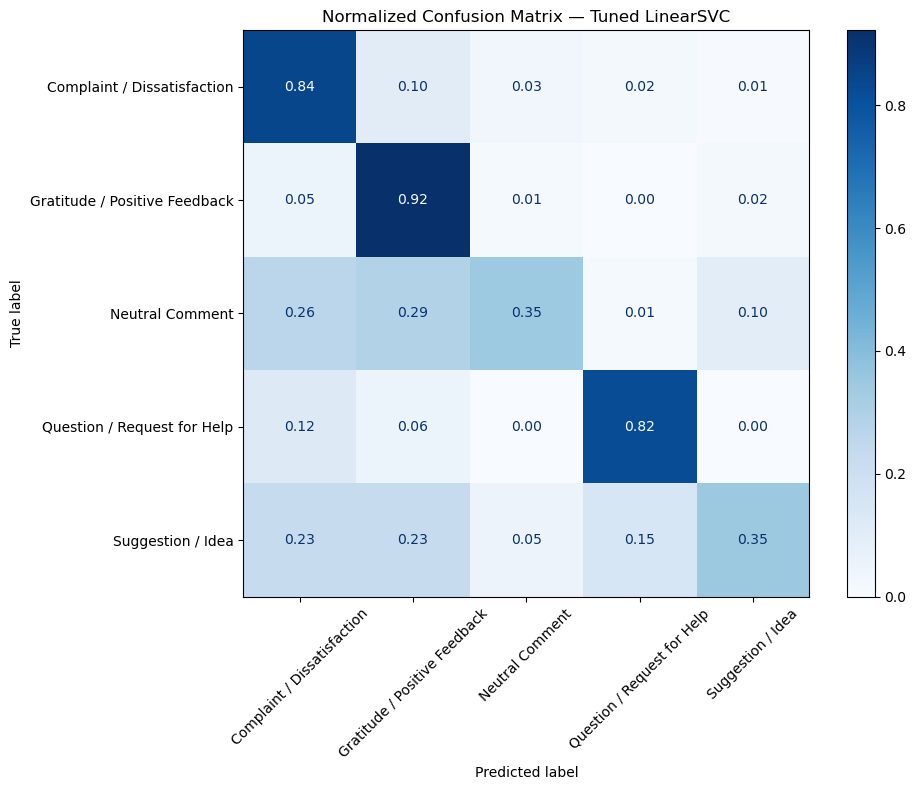

In [66]:
cm_tuned_svc_norm = confusion_matrix(
    y_test,
    tuned_svc_pred,
    labels=labels,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned_svc_norm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix — Tuned LinearSVC")
plt.tight_layout()
plt.show()

In [67]:
comparison_svc = pd.DataFrame([
    svc_metrics,
    tuned_svc_metrics
])

display(comparison_svc)

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,LinearSVC,0.863558,0.687452,0.643660,0.660190,0.858520
1,Tuned LinearSVC,0.857945,0.671504,0.655149,0.661667,0.855621


In [68]:
all_models_results = pd.DataFrame([
    baseline_logreg_metrics,
    tuned_logreg_metrics,
    nb_metrics,
    tuned_nb_metrics,
    svc_metrics,
    tuned_svc_metrics
])

all_models_results = all_models_results.sort_values(
    by="f1_macro",
    ascending=False
).reset_index(drop=True)

display(all_models_results)

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Tuned LinearSVC,0.857945,0.671504,0.655149,0.661667,0.855621
1,LinearSVC,0.863558,0.687452,0.643660,0.660190,0.858520
2,Tuned Logistic Regression,0.865717,0.695911,0.636743,0.658400,0.859376
3,Baseline Logistic Regression,0.827288,0.626171,0.681065,0.649073,0.835401
4,Tuned Naive Bayes,0.853195,0.700988,0.607168,0.639482,0.845049
5,Naive Bayes,0.809154,0.527684,0.401326,0.430523,0.768959


In [69]:
from pathlib import Path
import joblib
import json

# Папка для збереження моделі
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

# Метрики фінальної моделі
model_metrics = {
    "accuracy": accuracy_score(y_test, logreg_pred),
    "macro_precision": precision_score(y_test, logreg_pred, average="macro", zero_division=0),
    "macro_recall": recall_score(y_test, logreg_pred, average="macro", zero_division=0),
    "macro_f1": f1_score(y_test, logreg_pred, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_test, logreg_pred, average="weighted", zero_division=0)
}

# Усі потрібні артефакти для майбутнього Gradio demo
model_artifacts = {
    "model": logreg_model,
    "tfidf": tfidf,
    "class_names": list(logreg_model.classes_),
    "best_max_features": best_max_features,
    "metrics": model_metrics
}

# Зберігаємо модель + TF-IDF
joblib.dump(model_artifacts, MODEL_DIR / "intent_logreg_tfidf.joblib")

# Окремо зберігаємо метадані у JSON, щоб зручно було подивитись характеристики моделі
metadata = {
    "model_name": "TF-IDF + Logistic Regression",
    "task": "Ukrainian intent classification",
    "classes": list(logreg_model.classes_),
    "tfidf_params": {
        "ngram_range": [1, 2],
        "min_df": 2,
        "max_df": 0.95,
        "max_features": best_max_features,
        "sublinear_tf": True
    },
    "metrics": model_metrics
}

with open(MODEL_DIR / "model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print("Модель успішно збережено!")
print(f"Файл моделі: {MODEL_DIR / 'intent_logreg_tfidf.joblib'}")
print(f"Файл метаданих: {MODEL_DIR / 'model_metadata.json'}")

Модель успішно збережено!
Файл моделі: models\intent_logreg_tfidf.joblib
Файл метаданих: models\model_metadata.json


In [70]:
loaded_artifacts = joblib.load("models/intent_logreg_tfidf.joblib")

loaded_model = loaded_artifacts["model"]
loaded_tfidf = loaded_artifacts["tfidf"]
loaded_classes = loaded_artifacts["class_names"]

print("Модель завантажена успішно!")
print("Класи моделі:")
print(loaded_classes)

Модель завантажена успішно!
Класи моделі:
['Complaint / Dissatisfaction', 'Gratitude / Positive Feedback', 'Neutral Comment', 'Question / Request for Help', 'Suggestion / Idea']


In [71]:
test_message = "Не можу увійти в акаунт, допоможіть будь ласка"

cleaned_message = clean_text(test_message)
message_tfidf = loaded_tfidf.transform([cleaned_message])

predicted_intent = loaded_model.predict(message_tfidf)[0]

print("Текст:", test_message)
print("Очищений текст:", cleaned_message)
print("Передбачений інтент:", predicted_intent)

Текст: Не можу увійти в акаунт, допоможіть будь ласка
Очищений текст: не можу увійти в акаунт допоможіть будь ласка
Передбачений інтент: Question / Request for Help


In [72]:
test_message = "Було б добре додати темну тему в застосунок"

cleaned_message = clean_text(test_message)
message_tfidf = loaded_tfidf.transform([cleaned_message])

predicted_intent = loaded_model.predict(message_tfidf)[0]
probabilities = loaded_model.predict_proba(message_tfidf)[0]

confidence = probabilities.max()

print("Текст:", test_message)
print("Передбачений інтент:", predicted_intent)
print("Confidence:", round(confidence, 3))

Текст: Було б добре додати темну тему в застосунок
Передбачений інтент: Suggestion / Idea
Confidence: 0.358


In [75]:
import time
import pandas as pd

test_messages = [
    "Не можу увійти в акаунт, допоможіть будь ласка",
    "Дякую, все працює добре, дуже зручний сервіс",
    "Чому моя заявка так довго обробляється?",
    "Було б добре додати темну тему в застосунок",
    "Просто залишаю коментар щодо роботи сервісу",
    "Сервіс нормальний, але хотілося б швидшої відповіді",
    "Не дуже зручно, але загалом працює"
]

results = []

for message in test_messages:
    start_time = time.perf_counter()

    cleaned = clean_text(message)
    vector = loaded_tfidf.transform([cleaned])

    prediction = loaded_model.predict(vector)[0]
    probabilities = loaded_model.predict_proba(vector)[0]
    confidence = probabilities.max()

    end_time = time.perf_counter()
    execution_time = end_time - start_time

    results.append({
        "message": message,
        "predicted_intent": prediction,
        "confidence": round(confidence, 3),
        "execution_time_sec": round(execution_time, 4)
    })

results_df = pd.DataFrame(results)
display(results_df)

,message,predicted_intent,confidence,execution_time_sec
0,"Не можу увійти в акаунт, допоможіть будь ласка",Question / Request for Help,0.951,0.0015
1,"Дякую, все працює добре, дуже зручний сервіс",Gratitude / Positive Feedback,0.907,0.0020
2,Чому моя заявка так довго обробляється?,Complaint / Dissatisfaction,0.495,0.0018
3,Було б добре додати темну тему в застосунок,Suggestion / Idea,0.358,0.0017
4,Просто залишаю коментар щодо роботи сервісу,Suggestion / Idea,0.343,0.0016
5,"Сервіс нормальний, але хотілося б швидшої відп...",Complaint / Dissatisfaction,0.470,0.0017
6,"Не дуже зручно, але загалом працює",Complaint / Dissatisfaction,0.453,0.0017


In [77]:
statistics = {
    "total_messages": len(results_df),
    "avg_confidence": results_df["confidence"].mean(),
    "min_confidence": results_df["confidence"].min(),
    "max_confidence": results_df["confidence"].max(),
    "avg_execution_time_sec": results_df["execution_time_sec"].mean(),
    "min_execution_time_sec": results_df["execution_time_sec"].min(),
    "max_execution_time_sec": results_df["execution_time_sec"].max()
}

statistics

{'total_messages': 7,
 'avg_confidence': np.float64(0.5681428571428572),
 'min_confidence': 0.343,
 'max_confidence': 0.951,
 'avg_execution_time_sec': np.float64(0.0017142857142857144),
 'min_execution_time_sec': 0.0015,
 'max_execution_time_sec': 0.002}

In [78]:
results_df = results_df.copy()
results_df["message_id"] = range(1, len(results_df) + 1)

results_df

,message,predicted_intent,confidence,execution_time_sec,message_id
0,"Не можу увійти в акаунт, допоможіть будь ласка",Question / Request for Help,0.951,0.0015,1
1,"Дякую, все працює добре, дуже зручний сервіс",Gratitude / Positive Feedback,0.907,0.0020,2
2,Чому моя заявка так довго обробляється?,Complaint / Dissatisfaction,0.495,0.0018,3
3,Було б добре додати темну тему в застосунок,Suggestion / Idea,0.358,0.0017,4
4,Просто залишаю коментар щодо роботи сервісу,Suggestion / Idea,0.343,0.0016,5
5,"Сервіс нормальний, але хотілося б швидшої відп...",Complaint / Dissatisfaction,0.470,0.0017,6
6,"Не дуже зручно, але загалом працює",Complaint / Dissatisfaction,0.453,0.0017,7


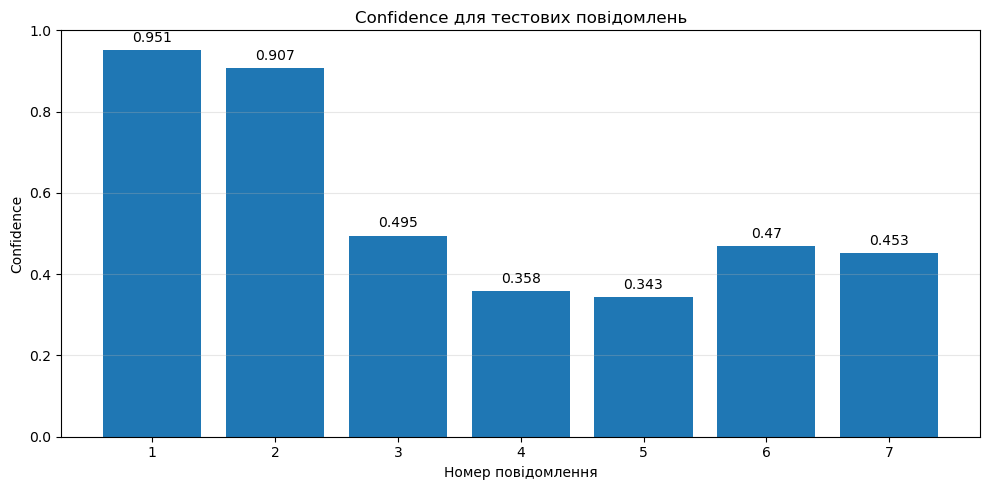

In [79]:
plt.figure(figsize=(10, 5))

plt.bar(results_df["message_id"], results_df["confidence"])

plt.title("Confidence для тестових повідомлень")
plt.xlabel("Номер повідомлення")
plt.ylabel("Confidence")
plt.xticks(results_df["message_id"])
plt.ylim(0, 1)

for x, y in zip(results_df["message_id"], results_df["confidence"]):
    plt.text(x, y + 0.02, str(round(y, 3)), ha="center")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

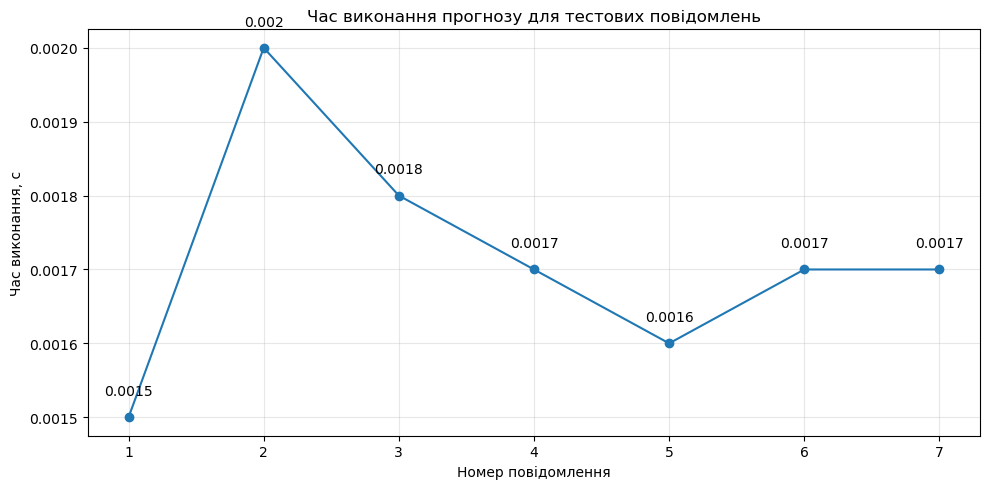

In [80]:
plt.figure(figsize=(10, 5))

plt.plot(
    results_df["message_id"],
    results_df["execution_time_sec"],
    marker="o"
)

plt.title("Час виконання прогнозу для тестових повідомлень")
plt.xlabel("Номер повідомлення")
plt.ylabel("Час виконання, с")
plt.xticks(results_df["message_id"])

for x, y in zip(results_df["message_id"], results_df["execution_time_sec"]):
    plt.text(x, y + 0.00003, str(round(y, 4)), ha="center")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

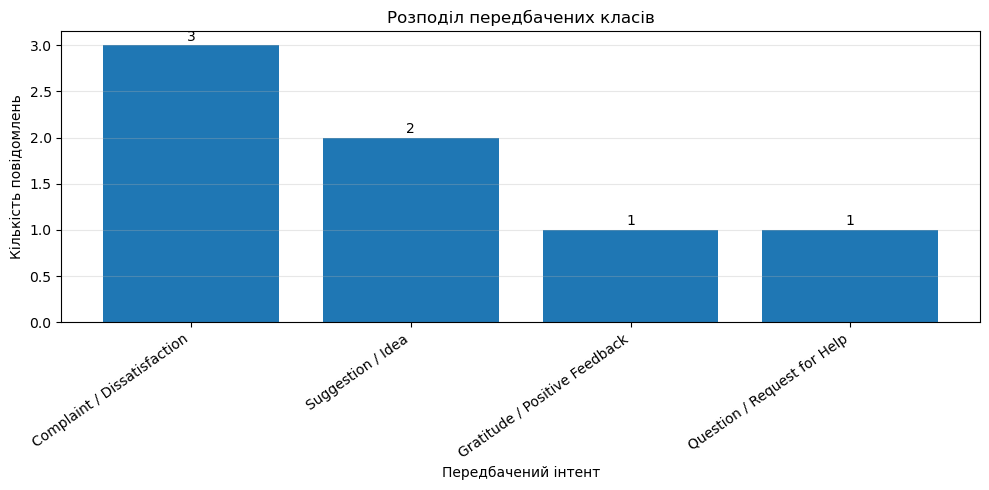

In [81]:
class_counts = results_df["predicted_intent"].value_counts()

plt.figure(figsize=(10, 5))

plt.bar(class_counts.index, class_counts.values)

plt.title("Розподіл передбачених класів")
plt.xlabel("Передбачений інтент")
plt.ylabel("Кількість повідомлень")
plt.xticks(rotation=35, ha="right")

for x, y in zip(class_counts.index, class_counts.values):
    plt.text(x, y + 0.05, str(y), ha="center")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()